In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Ligue1_lens_data import get_team_stats

plt.rcParams['font.family'] = "Malgun Gothic"
plt.rcParams['axes.unicode_minus'] = False


In [14]:
df = pd.read_csv('https://www.football-data.co.uk/mmz4281/2526/F1.csv')
df.sort_index(ascending=False).head(10)

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
161,F1,18/01/2026,19:45,Lyon,Brest,2,1,H,2,0,...,1.83,2.03,NaN,NaN,1.85,2.03,1.80,1.99,1.92,2.05
160,F1,18/01/2026,16:15,Rennes,Le Havre,1,1,D,0,0,...,2.05,1.80,NaN,NaN,2.05,1.87,1.96,1.82,2.08,1.90
159,F1,18/01/2026,16:15,Nantes,Paris FC,1,2,A,0,1,...,1.85,2.00,NaN,NaN,1.91,2.00,1.85,1.92,1.96,2.02
158,F1,18/01/2026,14:00,Strasbourg,Metz,2,1,H,2,1,...,1.93,1.93,NaN,NaN,1.93,1.93,1.91,1.87,2.00,1.96
157,F1,17/01/2026,20:05,Angers,Marseille,2,5,A,1,4,...,1.85,2.00,NaN,NaN,1.89,2.00,1.84,1.93,1.88,2.11
156,F1,17/01/2026,18:00,Toulouse,Nice,5,1,H,2,0,...,2.00,1.85,NaN,NaN,2.00,1.90,1.90,1.83,2.04,1.94
155,F1,17/01/2026,16:00,Lens,Auxerre,1,0,H,0,0,...,2.05,1.75,NaN,NaN,2.10,1.90,2.01,1.78,2.21,1.79
154,F1,16/01/2026,20:00,Paris SG,Lille,3,0,H,1,0,...,1.98,1.88,NaN,NaN,1.98,1.90,1.91,1.87,2.07,1.91
153,F1,16/01/2026,18:00,Monaco,Lorient,1,3,A,0,0,...,1.75,2.05,NaN,NaN,1.83,2.05,1.77,2.01,1.85,2.16
152,F1,04/01/2026,19:45,Paris SG,Paris FC,2,1,H,1,0,...,1.98,1.88,2.0,1.88,2.40,1.88,2.04,1.76,2.03,1.93


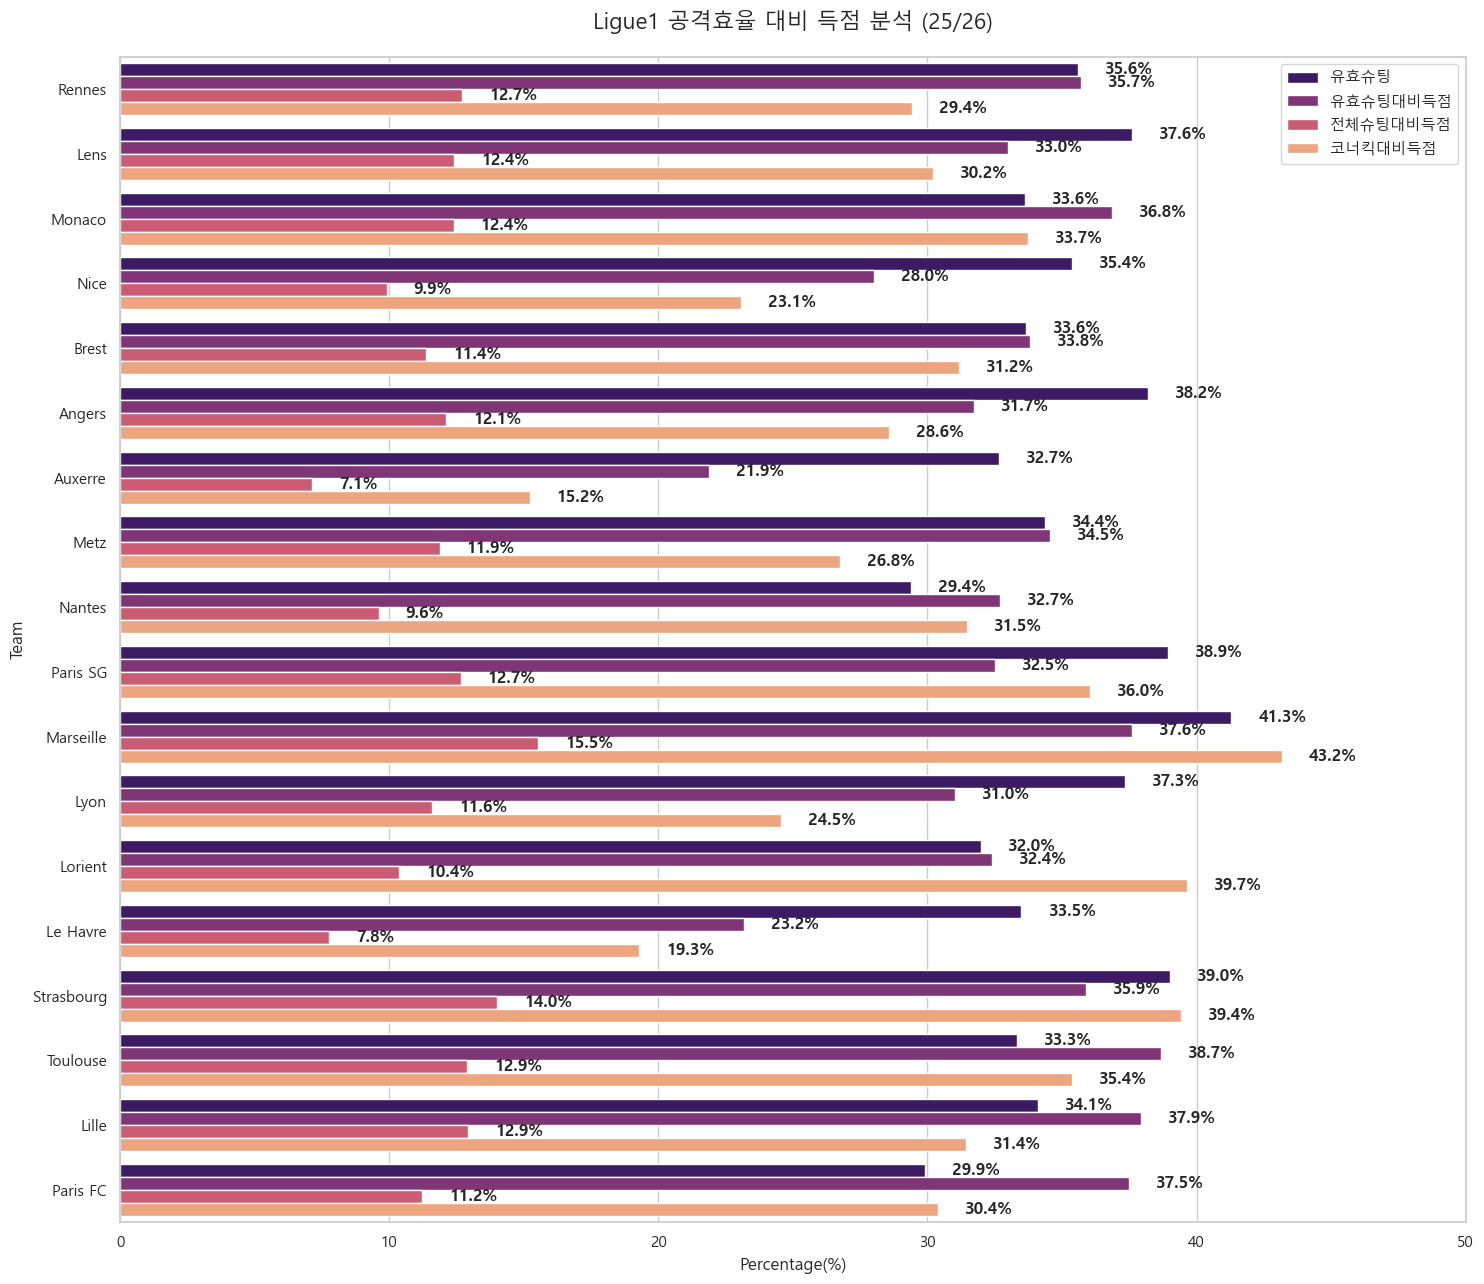

In [ ]:
# 1. 데이터에 있는 모든 팀 이름을 중복 없이 가져오기
all_teams = df['HomeTeam'].unique()
results = []

# 원래는 3개의 팀(랑스, psg, metz) 만 쓸려고 만든 df_teams
# df_teams = df[['HomeTeam','AwayTeam','FTHG','FTAG','FTR','HS','AS','HST','AST']] # 홈, 원정, 홈 득점, 원정 득점, 승무패, 홈 슈팅, 원정 슈팅, 홈 유효슈팅, 원정 유효슈팅

# 2. for문으로 모든 팀을 하나씩 분석
for team in all_teams:
  team_list = get_team_stats(df, team)
  results.extend(team_list)

df_compare = pd.DataFrame(results)
# 공격효율 관련 지표만 필터링
offense_metrics = ['유효슈팅', '유효슈팅대비득점', '전체슈팅대비득점', '코너킥대비득점']
df_offense = df_compare[df_compare['Metric'].isin(offense_metrics)]

# 그래프 스타일 설정
sns.set_theme(style='whitegrid')
plt.figure(figsize=(15,13))
# 한글 설정
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
# 3. 가로형 바 그래프 (18개 팀 전체)
ax = sns.barplot(
  data=df_offense, 
  x='Value', 
  y='Team', 
  hue='Metric', # 색상을 구분할 기준
  palette='magma', 
  legend=True # 범례 사용할시 True로
  )

# 수치 표시
for p in ax.patches: # p는 각 막대(객체)를 의미
  # width : 막대의 가로 길이(Value값)를 가져옴
  width = p.get_width()
  if width > 0: # 0보다 큰 값일 때만 텍스트를 그립니다
    # plt.text(x좌표, y좌표, 표시할 내용, 옵션)
    plt.text(
      width + 1, # 막대 끝에서 1만큼 오른쪽 여백
      p.get_y() + p.get_height()/2, # 막대의 세로 위치(y)에서 높이의 절반을 더해 '중앙에 맞춤
      f'{width:.1f}%', # width 값을 소수점 첫째 자리까지 문자열로 포맷팅
      va='center',  # 수직 정렬을 중앙으로 설정
      fontweight='bold' # 글씨는 굵게
    )


# 타이틀을 포함 마무리 
plt.title("Ligue1 공격효율 대비 득점 분석 (25/26)",fontsize=16, pad=20)
plt.xlabel('Percentage(%)')
plt.xlim(0, 50) # 수치 표시 공간 확보
plt.tight_layout()

plt.legend()
plt.show()


C:\Users\ojy05\AppData\Local\Temp\ipykernel_22088\1532563703.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


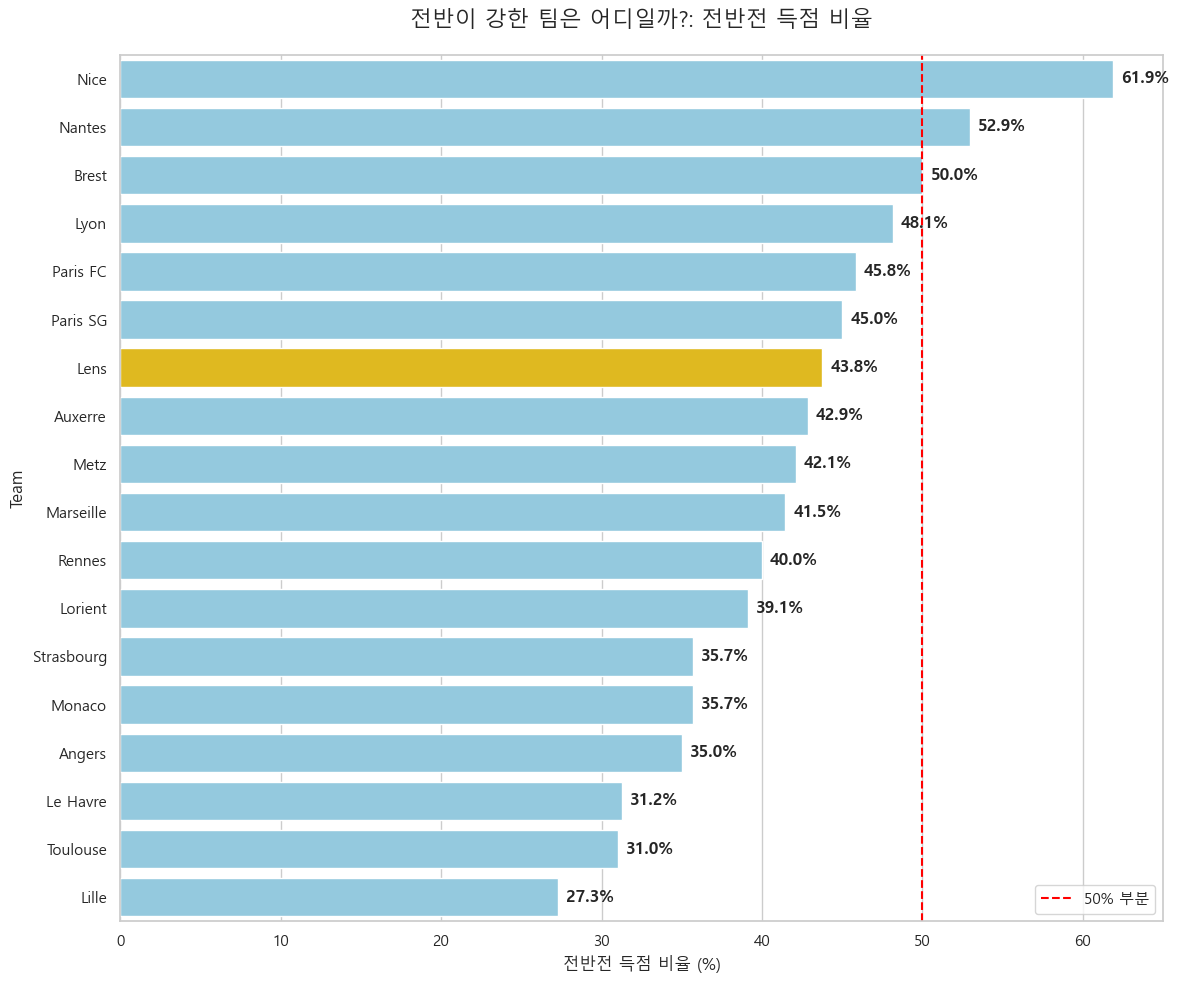

In [ ]:
# 전반전 비중 지표만 필터링 및 정렬
df_half = df_compare[df_compare['Metric'] == '전반전득점']
df_half = df_half.sort_values('Value', ascending=False) # 높은 순으로 정렬)

plt.figure(figsize=(12,10))
# 비중이 50% 넘는 팀은 눈에 띄게 색상을 다르게 줄 수도 있습니다.
colors = ['#FFCC00' if x == 'Lens' else 'skyblue' for x in df_half['Team']]

ax2 = sns.barplot(
  data = df_half,
  x= 'Value',
  y='Team',
  palette=colors,
  legend=True
)

# 50% 가이드라인 (전반/후반이 반반인 기준선)
plt.axvline(50, color='red', linestyle='--', label='50% 부분')

# 수치 표시
for p in ax2.patches:
    width = p.get_width()
    ax2.text(width + 0.5, p.get_y() + p.get_height()/2, f'{width:.1f}%', va='center', fontweight='bold')

plt.title("전반이 강한 팀은 어디일까?: 전반전 득점 비율", fontsize=16, pad=20)
plt.xlabel("전반전 득점 비율 (%)")
plt.legend()
plt.tight_layout()
plt.show()

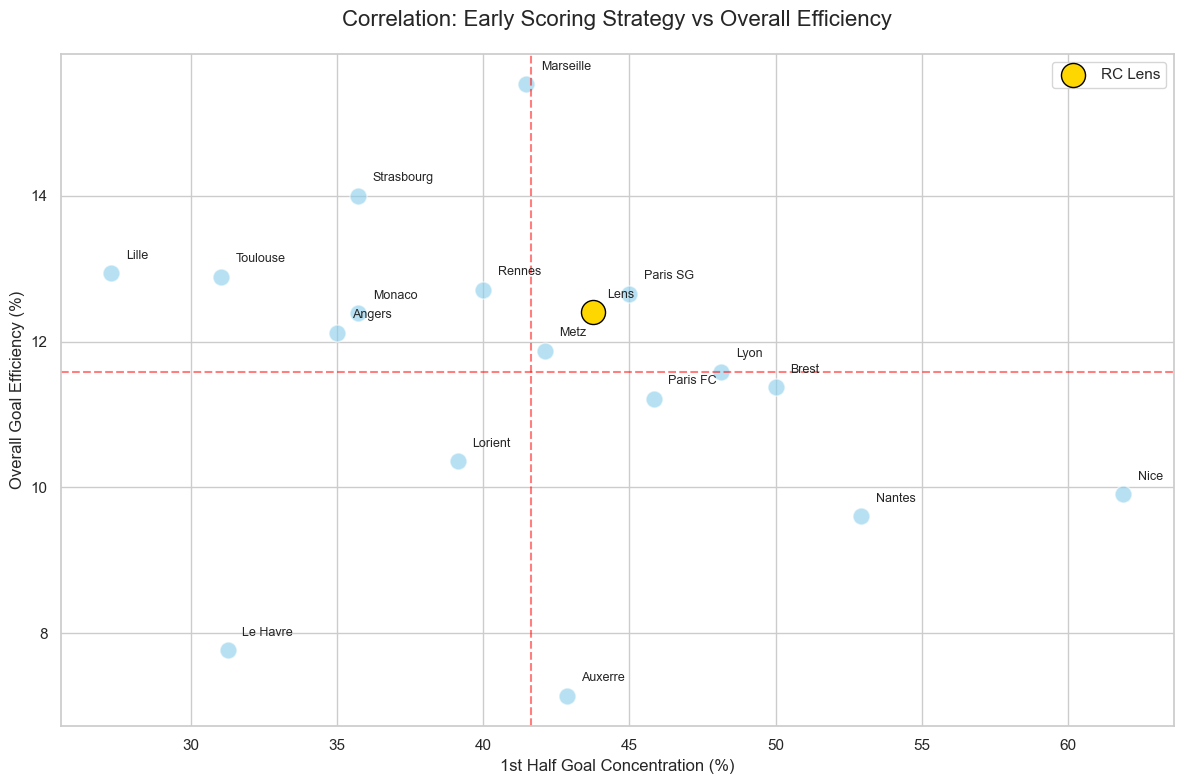

In [11]:
# 1. 데이터 준비 (Metric별로 나누어져 있는 데이터를 가로로 펼치기)
# 'Team'을 기준으로 각 지표(Metric)들을 컬럼으로 변환합니다.
df_pivot = df_compare.pivot(index='Team', columns='Metric', values='Value (%)').reset_index()

# 2. 산점도 그리기
plt.figure(figsize=(12, 8))
sns.set_theme(style='whitegrid')

# 산점도 생성 (X: 전반전 비중, Y: 전체 득점 효율)
ax3 = sns.scatterplot(
    data=df_pivot, 
    x='전반전득점', 
    y='전체슈팅대비득점', 
    s=150,               # 점의 크기
    alpha=0.6,           # 투명도
    color='skyblue'
)

# 3. 랑스(Lens)만 특별하게 강조
lens_data = df_pivot[df_pivot['Team'] == 'Lens']
plt.scatter(
    lens_data['전반전득점'], 
    lens_data['전체슈팅대비득점'], 
    color='gold', 
    s=300, 
    edgecolors='black', 
    label='RC Lens'
)

# 4. 각 점 옆에 팀 이름 표시
for i in range(df_pivot.shape[0]):
    plt.text(
        df_pivot['전반전득점'][i] + 0.5, 
        df_pivot['전체슈팅대비득점'][i] + 0.2, 
        df_pivot['Team'][i], 
        fontsize=9
    )

# 5. 리그 평균 가이드라인 (평균보다 높은지 낮은지 확인용)
plt.axvline(df_pivot['전반전득점'].mean(), color='red', linestyle='--', alpha=0.5)
plt.axhline(df_pivot['전체슈팅대비득점'].mean(), color='red', linestyle='--', alpha=0.5)

# 6. 마무리
plt.title("Correlation: Early Scoring Strategy vs Overall Efficiency", fontsize=16, pad=20)
plt.xlabel("1st Half Goal Concentration (%)")
plt.ylabel("Overall Goal Efficiency (%)")
plt.legend()
plt.tight_layout()
plt.show()